### Things I analysed before working on the EDA portion of my project :

- During 2.56 seconds, the phone recorded signals repeatedly with a frequency of 50Hz giving the 128 values (50 * 2.56) for each measurements.Then they compute statisics from these sequences such as mean, standard deviation, energy, entropy, max, min and so on.
- These statistical data becomes 561 features in the dataset where each row is calculated using data collected in the same 2.56 seconds.
- This is a multi class classification problem where we are classifying with the given features whether the individual is sitting, laying, standing, walking, walking upstairs or walking downstairs.

#### Hypothesis :

- To test or classify, acceleration would be a great feature to look into as it can divided the classification into two sub-categories : stationary (standing, sitting and laying) and in-motion (walking, walking upstairs and walking downstairs).
- Some features are unique and useful, but because many are derived from the same underlying signals, I expect groups of features to be strongly correlated.
- Standing and Sitting can be distinguished using the different gravity orientation.
- Walking in a horizontal plane and walking in an incline plane might have different standard deviation of acceleration.

---

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
X_train = pd.read_csv('../data/UCI-HAR Dataset/train/X_train.txt', sep = r'\s+', header = None)
y_train = pd.read_csv('../data/UCI-HAR Dataset/train/y_train.txt', sep = r'\s+', header = None)
X_test = pd.read_csv('../data/UCI-HAR Dataset/test/X_test.txt', sep = r'\s+', header = None)
y_test = pd.read_csv('../data/UCI-HAR Dataset/test/y_test.txt', sep = r'\s+', header = None)

In [4]:
X_train.shape

(7352, 561)

In [5]:
X_train.head(1)

,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.0304,-0.464761,-0.018446,-0.841247,0.179941,-0.058627


The columns have no name and we are provided with the column name in a separate text file.

In [ ]:
with open('../data/UCI-HAR Dataset/features.txt', 'r') as file:
    column_name = [line.strip().split(maxsplit=1)[1] for line in file if line.strip()]

X_train.columns = column_name
X_test.columns = column_name

Now, if we again looked into the dataset, we have :

In [7]:
X_train.sample(5)

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
4712,0.313751,-0.007304,-0.066969,-0.952623,-0.932828,-0.809873,-0.959747,-0.937198,-0.824554,-0.867486,...,-0.091968,-0.281376,-0.669671,-0.047440,-0.031531,0.044242,-0.589121,-0.607552,0.208310,0.274216
6243,0.285388,0.018488,-0.045187,-0.951032,-0.861241,-0.916772,-0.960210,-0.855654,-0.926574,-0.865596,...,0.207769,-0.292889,-0.667037,0.052285,-0.017593,-0.823917,-0.139011,-0.773750,0.253292,-0.002140
1688,0.279555,-0.017815,-0.110400,-0.995351,-0.990511,-0.984730,-0.995963,-0.990300,-0.985563,-0.937335,...,0.272613,-0.656142,-0.864948,0.433299,-0.004267,-0.598436,0.399287,0.489686,-0.729817,-0.257585
6222,0.269326,-0.022684,-0.110366,-0.310263,-0.089196,-0.251056,-0.349863,-0.129886,-0.230938,-0.031361,...,0.136056,-0.011203,-0.380556,0.115489,-0.040702,-0.956927,-0.121166,-0.511607,0.252989,0.324839
57,0.278007,-0.017803,-0.108965,-0.994425,-0.994873,-0.994886,-0.994939,-0.993994,-0.995450,-0.938974,...,0.394506,-0.684497,-0.901888,0.751089,0.626432,0.263401,-0.646225,0.398881,-0.546717,-0.431200


In [8]:
X_train.duplicated().sum()

np.int64(0)

In [9]:
y_train.head()

,0
0,5
1,5
2,5
3,5
4,5


In [10]:
y_train.shape

(7352, 1)

In [11]:
y_train.columns = ['Label']

y_train['Label'].value_counts()

Label
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64

<Axes: xlabel='Label'>

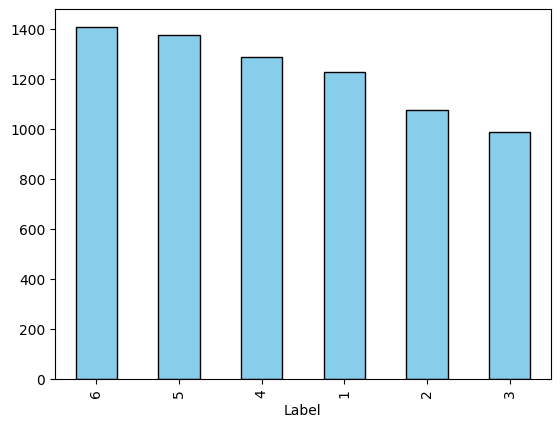

In [12]:
y_train_count = y_train['Label'].value_counts()

y_train_count.plot(kind = 'bar', color = 'skyblue', edgecolor = 'black')

---

Let's test the first hypothesis!

***To test or classify, acceleration would be a great feature to look into as it can divided the classification into two sub-categories : stationary (standing, sitting and laying) and in-motion (walking, walking upstairs and walking downstairs).***

<Axes: xlabel='Label', ylabel='tBodyAccMag-mean()'>

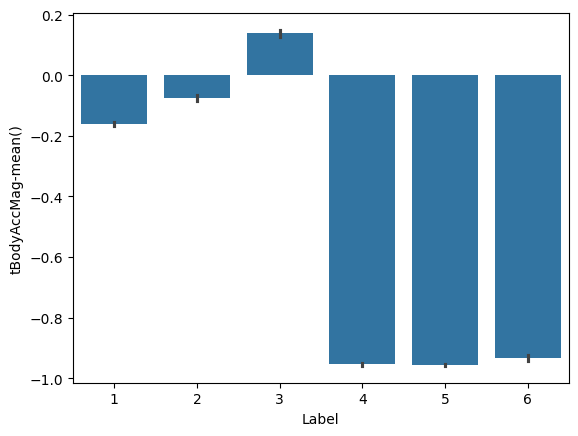

In [13]:
sns.barplot(x = y_train.iloc[:, 0], y = X_train['tBodyAccMag-mean()'])

This feature appears to separate dynamic activities from static activities!

But, we still have to think about which feature can further classify the categories with similar tBodyAccMag-mean() for which we can test our another hypothesis :

***Standing and Laying can be distinguished using the different gravity orientation.***

<Axes: xlabel='Label', ylabel='tGravityAcc-mean()-X'>

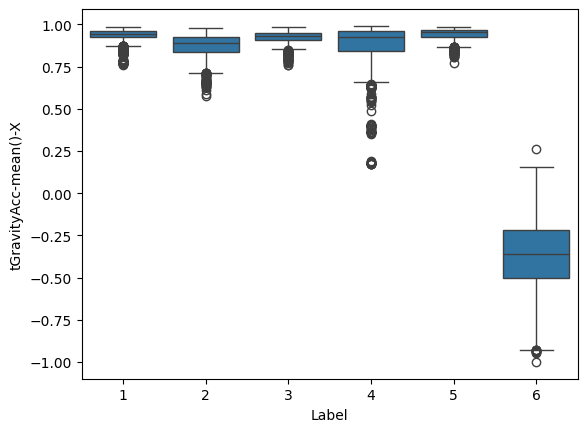

In [14]:
sns.boxplot(x = y_train.iloc[:, 0], y = X_train['tGravityAcc-mean()-X'])

<Axes: xlabel='Label', ylabel='tGravityAcc-mean()-Y'>

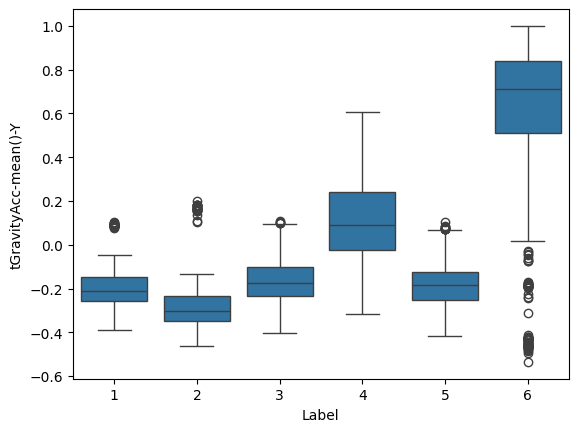

In [15]:
sns.boxplot(x = y_train.iloc[:, 0], y = X_train['tGravityAcc-mean()-Y'])

<Axes: xlabel='Label', ylabel='tGravityAcc-mean()-Z'>

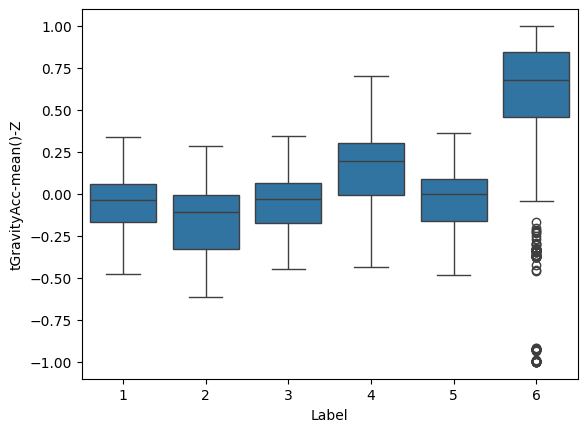

In [16]:
sns.boxplot(x = y_train.iloc[:, 0], y = X_train['tGravityAcc-mean()-Z'])

In the given graphs, we can clearly see that the distribution of the tGravityAcc-mean()-XYZ for laying is completely different from every other class making this feature extremely useful for identifying LAYING.

For another hypothesis of distinguishing walking in a horizontal plane and walking in an inclined plane, we have :

<Axes: xlabel='Label', ylabel='tBodyAccMag-std()'>

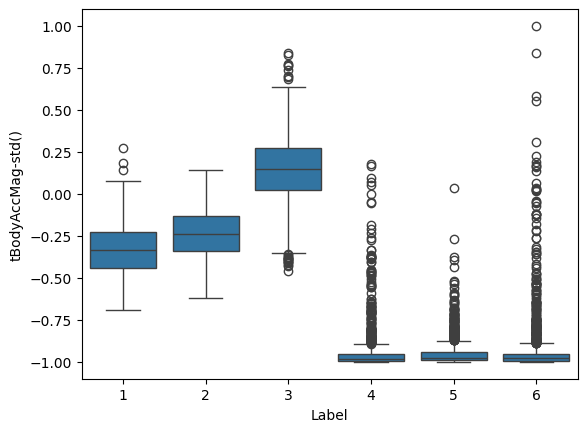

In [ ]:
sns.boxplot(x = y_train.iloc[:, 0], y = X_train['tBodyAccMag-std()'])

This graph shows that walking downstairs produces the highest acceleration variability.

Hence, this feature provides insightful information to differentiate walking downstairs.

---

Till now, we have figured out features to sub categorize static and dynamic activities as well as distinguish the activities laying and walking upstairs. The main issue we are facing here is figuring out the features that can help us further classify between standing and sitting, and walking and walking upstairs. So, let's create some further hypothesis!

- Gyroscopic measurement might help differentiate walking upstairs from walking.

First of all, let's check the gyroscopic measurements.

<Axes: xlabel='Label', ylabel='fBodyGyro-energy()-Z'>

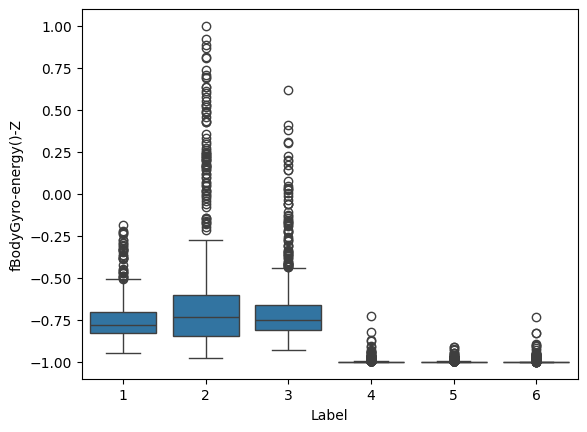

In [ ]:
sns.boxplot(x = y_train.iloc[:, 0], y = X_train['fBodyGyro-energy()-Z'])

Testing with tgyro and fgyro mean, max, min, energy and std, it looks like the difference is there but not significant enough. Hence, this hypothesis did not work.

But a feature does not need to solve the problem by itself.

Finally, as I was analysing the previous plots, i figured out that the tgravityacc mean Y box plot can actually distinguish between standing and sitting.

<Axes: xlabel='Label', ylabel='tBodyAccJerk-std()-Z'>

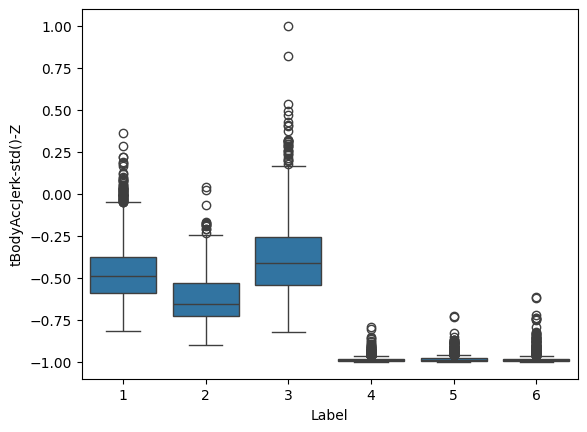

In [42]:
sns.boxplot(x = y_train.iloc[:, 0], y = X_train['tBodyAccJerk-std()-Z'])

For walking vs walking upstairs, acceleration jerk is one of few features I figured out to have quite distinguishable range of values.

---

The classifications can be solved with the following features :

- Static vs Dynamic : tBodyAccMag-mean() / tBodyAccMag-std()
- Laying vs Others : tGravityAcc-mean()-X / tGravityAcc-mean()-Z
- Sitting vs Standing : tGravityAcc-mean()-Y
- Walking Downstairs vs Other Walking Activities : tBodyAccMag-std()
- Walking vs Walking Upstairs : tBodyAccJerk-std()-Z

---